# Exact-K Rule: DiT Learning Analysis

**Rule**: Binary ±1 sequences of length D=36 where exactly K positions are +1.

**Model**: DiT-mini (6L, 6H, 384D), N=4096 training samples, 1M steps.

**K values**: 3, 4, 6, 8, 9, 12, 18

**Key insight** — dataset coverage varies dramatically:
| K | C(36,K) valid configs | Train coverage (N=4096) |
|---|---|---|
| 3 | 7,140 | 57.4% |
| 4 | 58,905 | 7.0% |
| 6 | 1,947,792 | 0.21% |
| 8 | 30,260,340 | 0.014% |
| 9 | 94,143,280 | 0.0043% |
| 12 | 1.25B | ~0 |
| 18 | 9.1B | ~0 |

In [19]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import comb
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from circuit_toolkit.plot_utils import saveallforms
SAVEROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIGDIR   = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/exactK_analysis"
SAVE_FIGS = True
os.makedirs(FIGDIR, exist_ok=True)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

K_VALS  = [3, 4, 6, 8, 9, 12, 18]
EXP_NAMES = [f"DiT_mini_exactK_N4096_D36_K{k}" for k in K_VALS]

# Color by K: plasma colormap
cmap = plt.cm.plasma
K_COLORS = {k: cmap(i / (len(K_VALS) - 1)) for i, k in enumerate(K_VALS)}

def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ['png', 'pdf']:
            fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"), dpi=150, bbox_inches='tight')

print("Experiment directories:")
for exp in EXP_NAMES:
    exists = os.path.isdir(os.path.join(SAVEROOT, exp))
    print(f"  {'✓' if exists else '✗'} {exp}")

Experiment directories:
  ✓ DiT_mini_exactK_N4096_D36_K3
  ✓ DiT_mini_exactK_N4096_D36_K4
  ✓ DiT_mini_exactK_N4096_D36_K6
  ✓ DiT_mini_exactK_N4096_D36_K8
  ✓ DiT_mini_exactK_N4096_D36_K9
  ✓ DiT_mini_exactK_N4096_D36_K12
  ✓ DiT_mini_exactK_N4096_D36_K18


In [2]:
# ── TensorBoard loader ────────────────────────────────────────────────────

def load_tb(exp_name, tags=None):
    tb_dir = os.path.join(SAVEROOT, exp_name, 'tensorboard')
    ea = EventAccumulator(tb_dir, size_guidance={'scalars': 0})
    ea.Reload()
    available = ea.Tags()['scalars']
    if tags is None:
        tags = available
    result = {}
    for tag in tags:
        if tag in available:
            events = ea.Scalars(tag)
            result[tag] = {
                'steps': np.array([e.step for e in events]),
                'vals':  np.array([e.value for e in events]),
            }
    return result

TAGS = ['train/loss', 'eval/k_correct_ratio', 'eval/sample_mem_ratio',
        'eval/nan_ratio_eps_1e-1', 'eval/mean_ones']

tb_data = {}
for k, exp in zip(K_VALS, EXP_NAMES):
    try:
        tb_data[k] = load_tb(exp, TAGS)
        n_steps = tb_data[k]['train/loss']['steps'][-1]
        print(f"K={k:2d}: loaded, last step={n_steps:,}")
    except Exception as e:
        print(f"K={k:2d}: ERROR — {e}")
        tb_data[k] = {}

K= 3: loaded, last step=1,000,000
K= 4: loaded, last step=1,000,000
K= 6: loaded, last step=1,000,000
K= 8: loaded, last step=1,000,000
K= 9: loaded, last step=1,000,000
K=12: loaded, last step=1,000,000
K=18: loaded, last step=1,000,000


## 1. Training curves — all K values

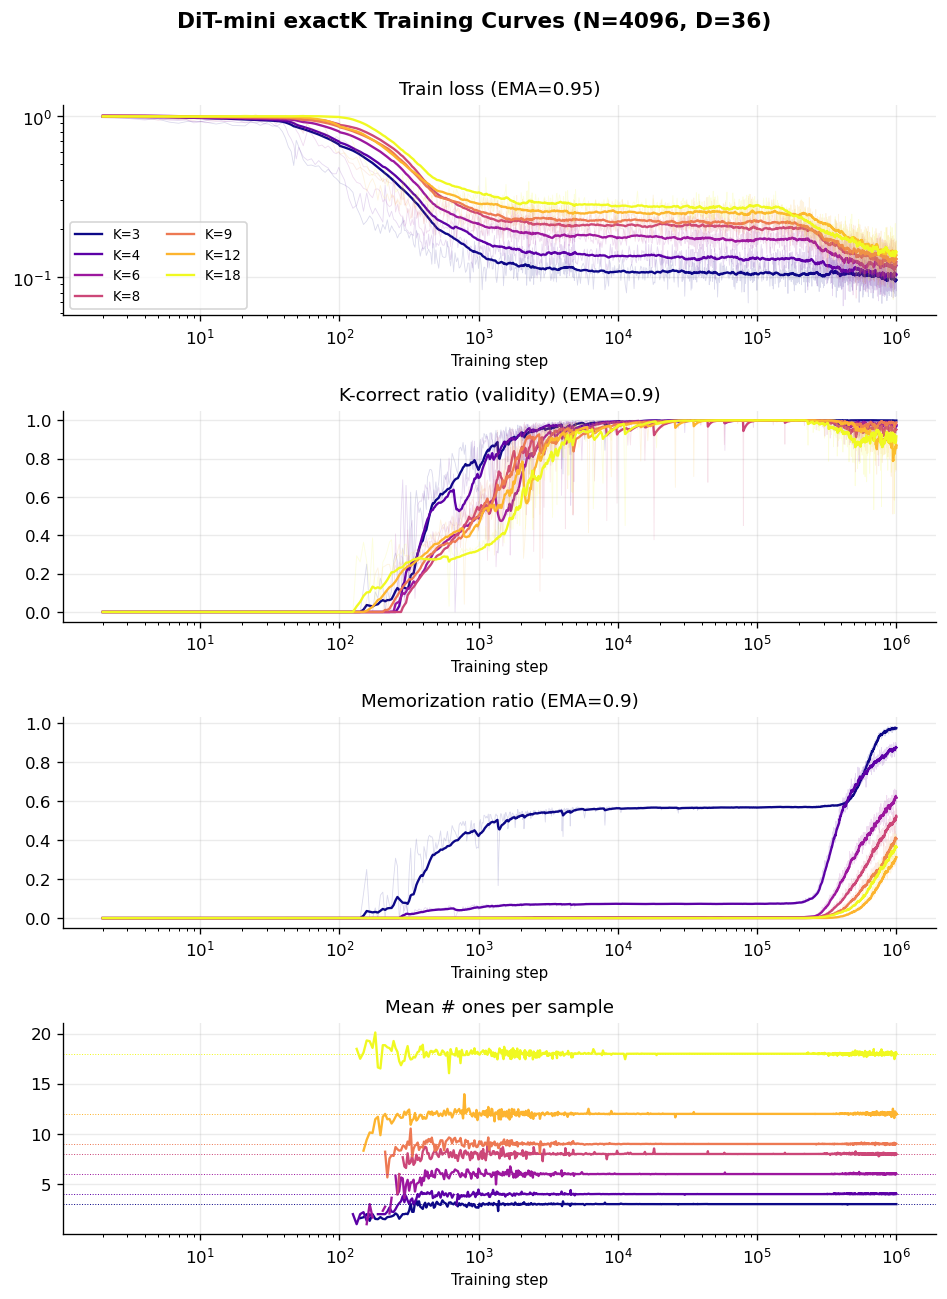

In [20]:
def ema_smooth(arr, alpha=0.1):
    if len(arr) == 0:
        return arr
    smoothed = np.zeros_like(arr, dtype=np.float32)
    smoothed[0] = arr[0]
    for i in range(1, len(arr)):
        smoothed[i] = (1-alpha) * arr[i] + alpha * smoothed[i-1]
    return smoothed

fig, axes = plt.subplots(4, 1, figsize=(8, 11), sharex=True)
fig.suptitle("DiT-mini exactK Training Curves (N=4096, D=36)", fontsize=13, fontweight='bold')

panels = [
    ('train/loss',           axes[0], 'Train loss (EMA=0.95)',          True, 0.95),
    ('eval/k_correct_ratio', axes[1], 'K-correct ratio (validity) (EMA=0.9)',     False, 0.9),
    ('eval/sample_mem_ratio',axes[2], 'Memorization ratio (EMA=0.9)',             False, 0.9),
    ('eval/mean_ones',       axes[3], 'Mean # ones per sample',         False, None,),
]

for tag_idx, (tag, ax, title, logy, ema_alpha) in enumerate(panels):
    for k in K_VALS:
        d = tb_data[k].get(tag)
        if d is None:
            continue
        yvals = d['vals']
        if ema_alpha is not None:
            ax.plot(d['steps'] + 1, yvals, color=K_COLORS[k], lw=0.5, label=None, alpha=0.15)
            yvals = ema_smooth(yvals, alpha=ema_alpha)
        ax.plot(d['steps'] + 1, yvals, color=K_COLORS[k], lw=1.4, label=f"K={k}")
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Training step', fontsize=9)
    ax.grid(alpha=0.25)
    # Ensure xtick values are shown for each panel
    ax.tick_params(axis='x', which='both', labelbottom=True)

# Add K reference line for mean_ones
ax_ones = axes[3]
for k in K_VALS:
    ax_ones.axhline(k, color=K_COLORS[k], lw=0.6, ls=':')

axes[0].legend(loc='lower left', fontsize=8, ncol=2)
plt.tight_layout(rect=[0,0,1,0.97])  # more room for the bottom colorbar
savefig(fig, 'training_curves_smoothed')
plt.show()

## 2. Final metrics vs K

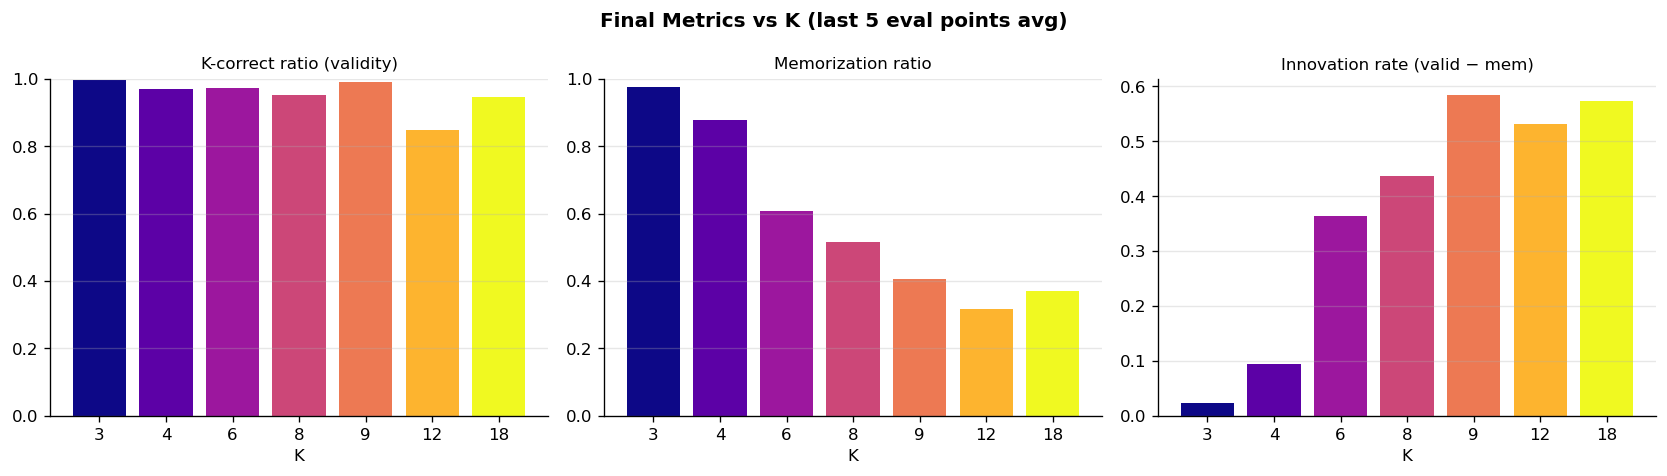

   K     valid       mem     innov         C(36,K)    coverage
   3     0.998     0.975     0.022           7,140      0.5737
   4     0.971     0.877     0.094          58,905      0.0695
   6     0.973     0.608     0.365       1,947,792      0.0021
   8     0.952     0.516     0.436      30,260,340      0.0001
   9     0.991     0.407     0.584      94,143,280      0.0000
  12     0.849     0.317     0.532   1,251,677,700      0.0000
  18     0.945     0.372     0.574   9,075,135,300      0.0000


In [21]:
def final_val(k, tag, n_avg=5):
    d = tb_data[k].get(tag)
    if d is None or len(d['vals']) == 0:
        return np.nan
    return float(d['vals'][-n_avg:].mean())

valid_final = [final_val(k, 'eval/k_correct_ratio') for k in K_VALS]
mem_final   = [final_val(k, 'eval/sample_mem_ratio') for k in K_VALS]
innov_final = [v - m for v, m in zip(valid_final, mem_final)]
n_valid     = [comb(36, k) for k in K_VALS]
coverage    = [min(4096/n, 1.0) for n in n_valid]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Final Metrics vs K (last 5 eval points avg)", fontsize=12, fontweight='bold')

colors = [K_COLORS[k] for k in K_VALS]

axes[0].bar([str(k) for k in K_VALS], valid_final, color=colors)
axes[0].set_title('K-correct ratio (validity)', fontsize=10)
axes[0].set_xlabel('K'); axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar([str(k) for k in K_VALS], mem_final, color=colors)
axes[1].set_title('Memorization ratio', fontsize=10)
axes[1].set_xlabel('K'); axes[1].set_ylim(0, 1); axes[1].grid(axis='y', alpha=0.3)

axes[2].bar([str(k) for k in K_VALS], innov_final, color=colors)
axes[2].set_title('Innovation rate (valid − mem)', fontsize=10)
axes[2].set_xlabel('K'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
savefig(fig, 'final_metrics_vs_K')
plt.show()

print(f"{'K':>4}  {'valid':>8}  {'mem':>8}  {'innov':>8}  {'C(36,K)':>14}  {'coverage':>10}")
for k, v, m, iv, n, c in zip(K_VALS, valid_final, mem_final, innov_final, n_valid, coverage):
    print(f"{k:4d}  {v:8.3f}  {m:8.3f}  {iv:8.3f}  {n:14,}  {c:10.4f}")

## 4. Memorization onset — when does mem > valid?

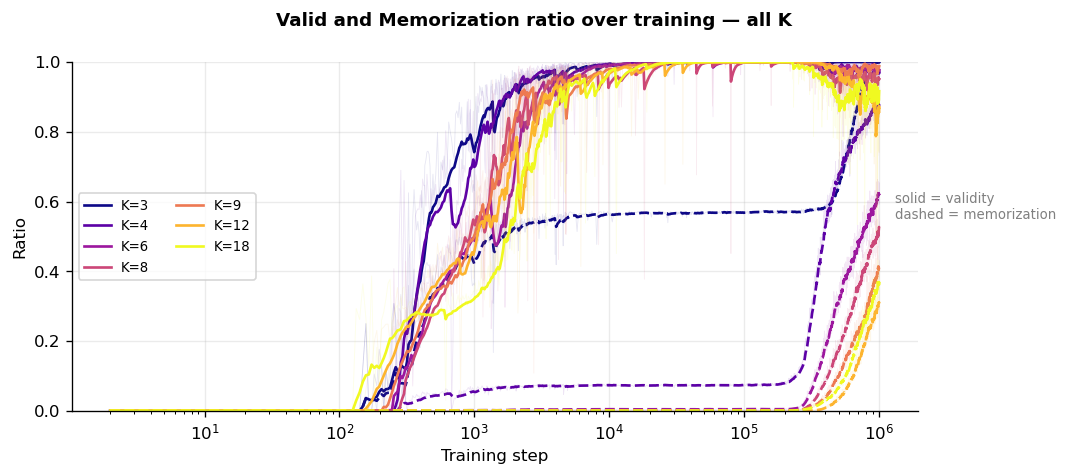

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle("Valid and Memorization ratio over training — all K", fontsize=11, fontweight='bold')

for k in K_VALS:
    v = tb_data[k].get('eval/k_correct_ratio')
    m = tb_data[k].get('eval/sample_mem_ratio')
    c = K_COLORS[k]
    if v is not None:
        ax.plot(v['steps']+1, v['vals'], color=c, lw=0.5, alpha=0.1)
        v_smooth = ema_smooth(v['vals'], alpha=0.9)
        ax.plot(v['steps']+1, v_smooth, color=c, lw=1.6, label=f"K={k}")
    if m is not None:
        ax.plot(m['steps']+1, m['vals'], color=c, lw=0.5, alpha=0.1)
        m_smooth = ema_smooth(m['vals'], alpha=0.9)
        ax.plot(m['steps']+1, m_smooth, color=c, lw=1.6, ls='--',)

ax.set_xscale('log')
ax.set_xlabel('Training step', fontsize=10)
ax.set_ylabel('Ratio', fontsize=10)
ax.set_ylim(0, 1)
ax.text(1.3e6, 0.55, 'solid = validity\ndashed = memorization', fontsize=8, color='gray')
ax.legend(fontsize=8, ncol=2, loc='center left'); ax.grid(alpha=0.25)
plt.tight_layout()
savefig(fig, 'valid_mem_overlay')
plt.show()

## 5. Sample images at key checkpoints

In [35]:
 
from PIL import Image
import numpy as np
 
 
def recolor_montage_border(
    img,
    tile=6,
    grid=8,
    border=1,
    outer=True,
    color=(255, 105, 180),  # pink; try (128,128,128) for gray
):
    """
    Replace the border pixels of a tiled montage with `color`.
 
    Parameters
    ----------
    img : PIL.Image
        The input montage (grayscale or RGB).
    tile : int
        Side length of each individual sample tile (e.g. 6 for MNIST-like 6x6).
    grid : int
        Number of tiles per row/column (e.g. 8 -> 64 tiles).
    border : int
        Thickness of the gridline in pixels.
    outer : bool
        Whether the montage also has a border on the outside.
        If you're not sure, leave detection to the helper below.
    color : tuple
        RGB color to paint the borders with.
    """
    # Promote to RGB so we can paint colored lines on a grayscale image
    rgb = img.convert("RGB")
    arr = np.array(rgb)  # (H, W, 3)
 
    H, W, _ = arr.shape
 
    # Sanity-check the layout
    expected_with    = grid * tile + (grid + 1) * border
    expected_without = grid * tile + (grid - 1) * border
    if (H, W) == (expected_with, expected_with):
        outer = True
    elif (H, W) == (expected_without, expected_without):
        outer = False
    else:
        # Fall back to the user-supplied flag, but warn.
        print(f"[warn] image is {H}x{W}; "
              f"expected {expected_with} (with outer) or "
              f"{expected_without} (without outer). "
              f"Using outer={outer}.")
 
    # Build a boolean mask of border pixels.
    mask = np.zeros((H, W), dtype=bool)
 
    # Vertical gridlines (columns of border pixels)
    if outer:
        # borders sit at columns [0..border), then after each tile, ..., last `border` cols
        x = 0
        for i in range(grid + 1):
            mask[:, x:x + border] = True
            x += border
            if i < grid:
                x += tile
    else:
        x = tile  # first border starts after the first tile
        for i in range(grid - 1):
            mask[:, x:x + border] = True
            x += border + tile
 
    # Horizontal gridlines (rows of border pixels)
    if outer:
        y = 0
        for i in range(grid + 1):
            mask[y:y + border, :] = True
            y += border
            if i < grid:
                y += tile
    else:
        y = tile
        for i in range(grid - 1):
            mask[y:y + border, :] = True
            y += border + tile
 
    # Paint
    arr[mask] = color
    return Image.fromarray(arr)
 
 
# ----------------------------- Auto-detect helper -----------------------------
 
def detect_layout(img, candidate_grids=(8, 10, 12, 16), candidate_tiles=(4, 6, 8, 10, 14, 16, 28)):
    """
    Try to figure out (grid, tile, border, outer) from the image dimensions.
    Returns the first plausible match.
    """
    W, H = img.size
    if W != H:
        print(f"[warn] non-square image {W}x{H}; layout detection may be off")
    side = W
    for g in candidate_grids:
        for t in candidate_tiles:
            for b in (1, 2):
                if side == g * t + (g + 1) * b:
                    return dict(grid=g, tile=t, border=b, outer=True)
                if side == g * t + (g - 1) * b:
                    return dict(grid=g, tile=t, border=b, outer=False)
    return None

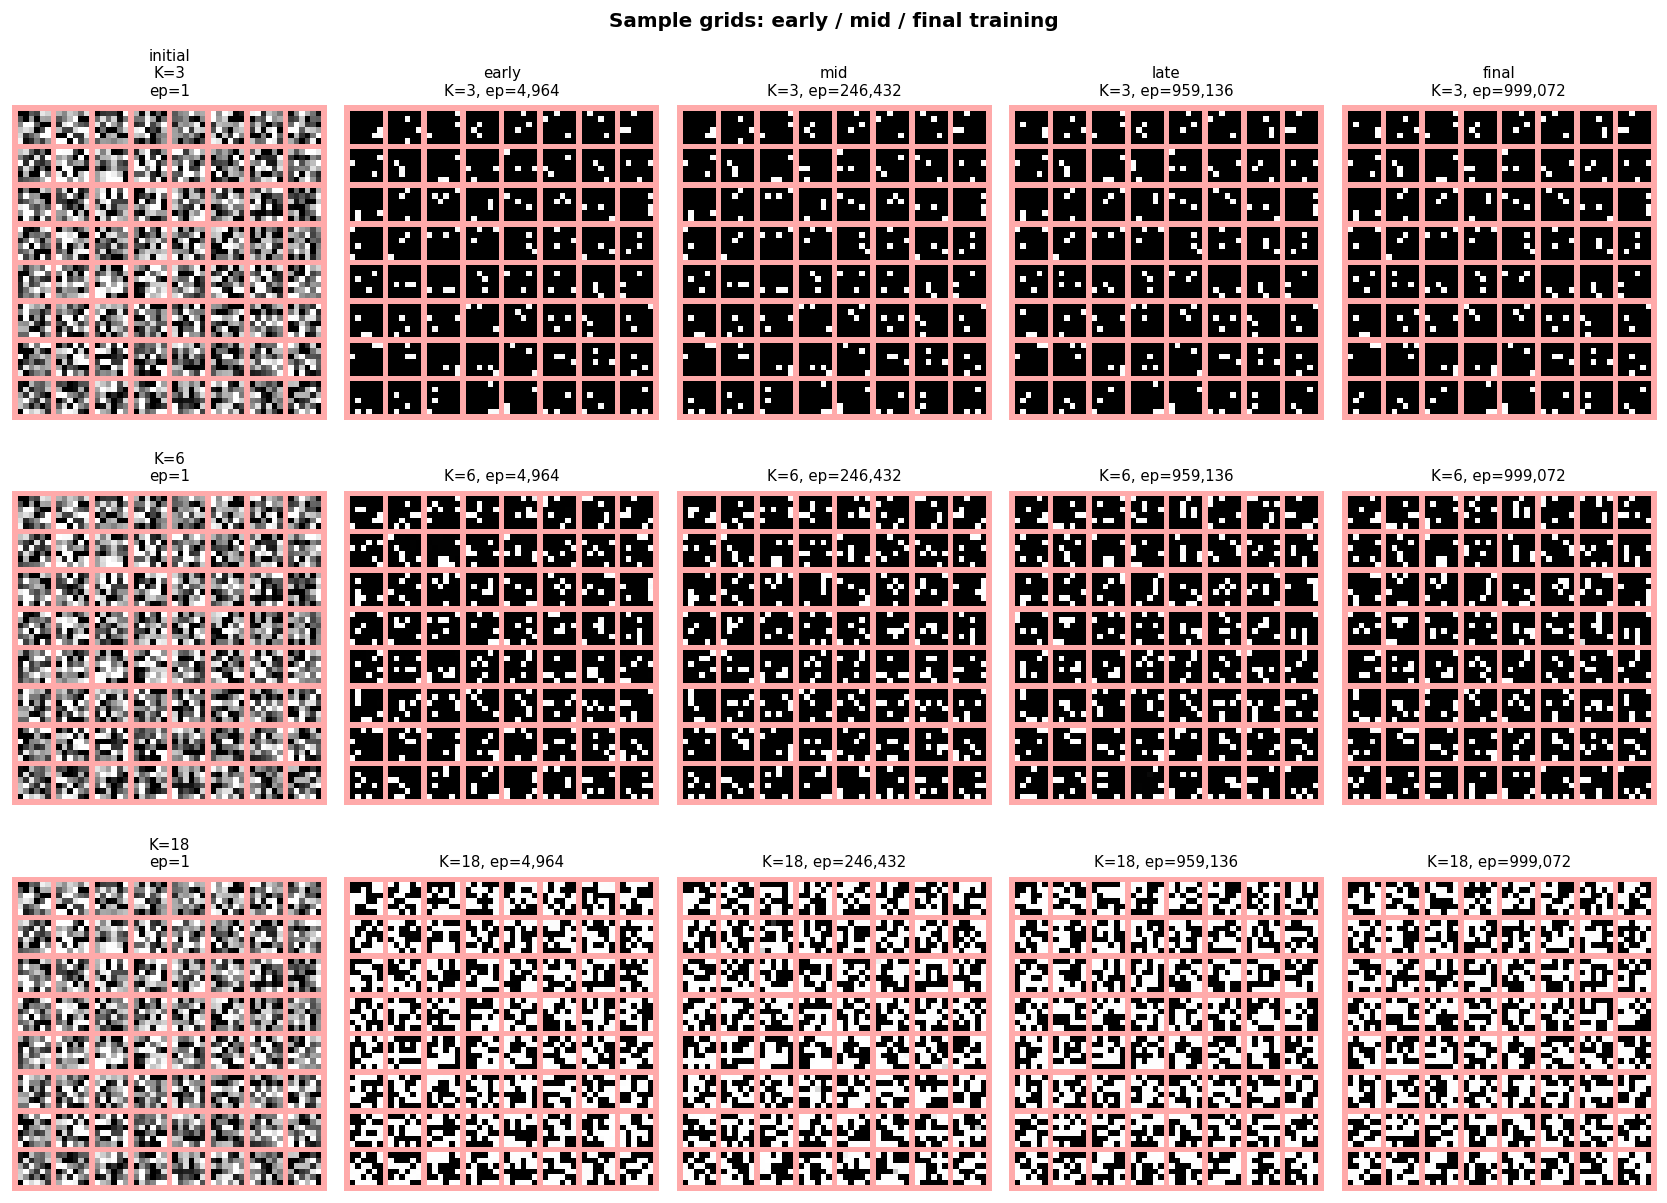

In [47]:
from PIL import Image

def get_sample_epochs(exp_name):
    samples_dir = os.path.join(SAVEROOT, exp_name, 'samples')
    pngs = sorted(f for f in os.listdir(samples_dir) if f.endswith('.png'))
    return pngs

# Show sample grids for K=3 (high coverage), K=6, K=18 (low coverage)
show_ks = [3, 6, 18]
show_epochs = ["initial", 'early', 'mid', 'late', 'final']  # first, middle, last

fig, axes = plt.subplots(len(show_ks), 5, figsize=(14, 3.5 * len(show_ks)))
fig.suptitle("Sample grids: early / mid / final training", fontsize=12, fontweight='bold')

for ri, k in enumerate(show_ks):
    exp = f"DiT_mini_exactK_N4096_D36_K{k}"
    pngs = get_sample_epochs(exp)
    indices = [0, len(pngs)//5, len(pngs)//2, -40, -1]
    for ci, idx in enumerate(indices):
        ax = axes[ri][ci]
        img_path = os.path.join(SAVEROOT, exp, 'samples', pngs[idx])
        img = Image.open(img_path)
        layout = detect_layout(img)      # {'grid':8,'tile':6,'border':1,'outer':True}
        out = recolor_montage_border(img, **layout, color=(255,170,170))
        ax.imshow(out)
        ax.axis('off')
        ep = pngs[idx].replace('samples_epoch_','').replace('.png','')
        ax.set_title(f"K={k}, ep={int(ep):,}" if ci > 0 else f"K={k}\nep={int(ep):,}",
                     fontsize=9)

for ax, lbl in zip(axes[0], show_epochs):
    ax.set_title(f"{lbl}\n" + ax.get_title(), fontsize=9)

plt.tight_layout()
savefig(fig, 'sample_grids_colored')
plt.show()

## 6. Coverage vs Final Valid/Mem — does coverage predict memorization?

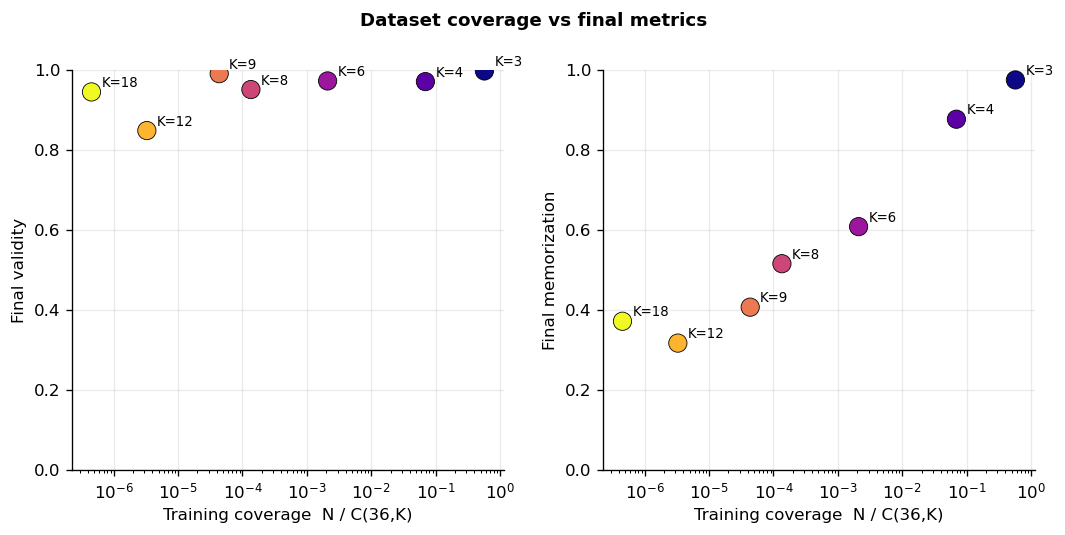

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
fig.suptitle("Dataset coverage vs final metrics", fontsize=11, fontweight='bold')

for ax, (ys, ylabel) in zip(axes, [(valid_final, 'Final validity'), (mem_final, 'Final memorization')]):
    sc = ax.scatter(coverage, ys, c=[K_COLORS[k] for k in K_VALS], s=120, zorder=3, edgecolors='k', lw=0.5)
    for k, x, y in zip(K_VALS, coverage, ys):
        ax.annotate(f"K={k}", (x, y), textcoords='offset points', xytext=(6,3), fontsize=8)
    ax.set_xscale('log')
    ax.set_xlabel('Training coverage  N / C(36,K)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, 1); ax.grid(alpha=0.25)

plt.tight_layout()
savefig(fig, 'coverage_vs_metrics')
plt.show()